# Shap and FAR synthetic data tests

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbimporter
import sklearn.ensemble
import xgboost as xgb
import shap

import synthetic_data as syn
import Ft_Att_Rank as far

# Load synthetic dataset

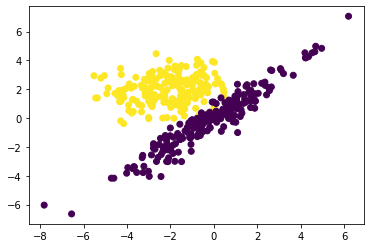

In [27]:
synth= syn.synthetic_data_generator(n=200,df=True)

X= synth.to_numpy()

plt.scatter(X[:,0],X[:,1],c=X[:,-1])

In [28]:
# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn= far.normalize_selected_cols(x_syn, x_syn.columns)

In [29]:
x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.396934,0.588149,0.695249,0.136927
1,0.357181,0.585355,0.606223,0.910129
2,0.350150,0.638643,0.216467,0.519418
3,0.461924,0.531671,0.007887,0.785046
4,0.345313,0.676201,0.683284,0.291382


# ML model setup

In [30]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,train_size=0.80,
                                                                                 random_state=1234)

In [32]:
# ML model - XGBoost random forest
xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.975

In [33]:
# ML model - Random forest
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)
rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.9875

# Shap test

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


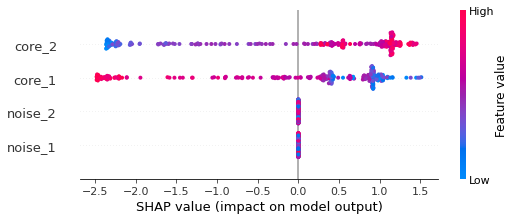

In [50]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [35]:
shap_values[1]

.values =
array([ 0.39092362, -2.3067544 , -0.01096973, -0.01029598], dtype=float32)

.base_values =
-0.062901944

.data =
array([0.42321598, 0.34782107, 0.81506178, 0.78935841])

# FAR test - Global version

In [14]:
repeat_train= 5
num_fts= len(train.columns)

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train, labels_test,repeat_train)

replace_ft= far.replace_values(train,train.columns,num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_retrain_v1(xgb_model, replace_ft, train, test, labels_train,
                                               labels_test,repeat_train)

In [15]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [16]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.457566
core_1     0.432628
noise_1    0.066659
noise_2    0.043147
dtype: float64

In [17]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.335876
noise_1    0.257055
noise_2    0.238988
core_1     0.168080
dtype: float64

In [18]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.337825
noise_1    0.253433
noise_2    0.236593
core_1     0.172149
dtype: float64

In [19]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.479091
core_1     0.464782
noise_1    0.033955
noise_2    0.022172
dtype: float64

# FAR test - Local version - data and target

In [36]:
X_tgt_in= x_syn.copy()
Y_tgt_in= y_syn.copy()

target_index= 1

target_insta= X_tgt_in.loc[X_tgt_in.index== target_index]
target_label= Y_tgt_in.loc[Y_tgt_in.index== target_index]

X_no_tgt= X_tgt_in.drop(target_insta.index)
Y_no_tgt= Y_tgt_in.drop(index= target_index)

# FAR test - KnnFold local version

In [37]:
acc_all_fts, acc_no_i, acc_no_ij= far.knnfold_remove_and_retrain(rf, X_no_tgt, Y_no_tgt, target_insta, 
                                                                 target_label, X_no_tgt.columns, 
                                                                 num_type='mean',test_size= 0.2)

In [38]:
num_fts= len(X_no_tgt.columns)

In [39]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [40]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.341325
noise_2    0.267828
core_1     0.218936
noise_1    0.171911
dtype: float64

In [41]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.341325
noise_2    0.267828
core_1     0.218936
noise_1    0.171911
dtype: float64

In [42]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.341325
noise_2    0.267828
core_1     0.218936
noise_1    0.171911
dtype: float64

In [43]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.341325
noise_2    0.267828
core_1     0.218936
noise_1    0.171911
dtype: float64

# FAR test - Knn-only local version

In [44]:
train_1, test_1, labels_train_1, labels_test_1= far.knn_train_test_split(X_no_tgt, Y_no_tgt, target_insta,
                                                                         target_label, test_size=0.2)

repeat_train= 5
num_fts= len(train_1.columns)

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train_1, test_1, labels_train_1, labels_test_1, 
                                          repeat_train)

replace_ft= far.replace_values(train,train.columns,num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_retrain_v1(xgb_model, replace_ft, train_1, test_1, labels_train_1, 
                                               labels_test_1, repeat_train)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


In [45]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [46]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.319163
noise_1    0.240298
noise_2    0.240264
core_1     0.200275
dtype: float64

In [47]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.313136
noise_2    0.240918
noise_1    0.239287
core_2     0.206658
dtype: float64

In [48]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.323562
core_2     0.248536
noise_1    0.217393
noise_2    0.210509
dtype: float64

In [49]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.338554
core_2     0.335123
noise_2    0.168154
noise_1    0.158169
dtype: float64

# FAR test - Global version PageRank

In [51]:
repeat_train= 5
num_fts= len(train.columns)

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train, labels_test,repeat_train)

replace_ft= far.replace_values(train,train.columns,num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_retrain_v1(xgb_model, replace_ft, train, test, labels_train,
                                               labels_test,repeat_train)

In [52]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# converts a matrix to a row stochastic matrix
st_matrix1= far.to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.to_row_stochastic_matrix(p_matrix4)

In [ ]:
# using networkx lib

In [53]:
far.run_lib_pr(st_matrix1, x_syn.columns)

core_2     0.408458
core_1     0.375106
noise_2    0.113259
noise_1    0.103177
dtype: float64

In [54]:
far.run_lib_pr(st_matrix2, x_syn.columns)

core_1     0.313278
core_2     0.260606
noise_2    0.218413
noise_1    0.207702
dtype: float64

In [55]:
far.run_lib_pr(st_matrix3, x_syn.columns)

core_1     0.313333
core_2     0.268520
noise_2    0.211901
noise_1    0.206246
dtype: float64

In [56]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_2     0.434581
core_1     0.410488
noise_2    0.080759
noise_1    0.074172
dtype: float64

In [61]:
# using my PageRank lib

In [57]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.498141
core_2     0.319192
noise_2    0.095243
noise_1    0.087424
dtype: float64

In [58]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_1     0.440185
core_2     0.280825
noise_2    0.142045
noise_1    0.136945
dtype: float64

In [59]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.442053
core_2     0.283003
noise_2    0.138836
noise_1    0.136108
dtype: float64

In [60]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.520393
core_2     0.317901
noise_2    0.083126
noise_1    0.078579
dtype: float64

# FAR test - KnnFold local version PageRank

In [64]:
acc_all_fts, acc_no_i, acc_no_ij= far.knnfold_remove_and_retrain(rf, X_no_tgt, Y_no_tgt, target_insta, 
                                                                 target_label, X_no_tgt.columns, 
                                                                 num_type='mean',test_size= 0.2)

In [65]:
num_fts= len(X_no_tgt.columns)

In [66]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# converts a matrix to a row stochastic matrix
st_matrix1= far.to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.to_row_stochastic_matrix(p_matrix4)

In [67]:
# using networkx lib

In [68]:
far.run_lib_pr(st_matrix1, x_syn.columns)

core_2     0.327565
noise_2    0.261989
core_1     0.222256
noise_1    0.188190
dtype: float64

In [69]:
far.run_lib_pr(st_matrix2, x_syn.columns)

core_2     0.263441
core_1     0.263210
noise_1    0.261715
noise_2    0.211634
dtype: float64

In [70]:
far.run_lib_pr(st_matrix3, x_syn.columns)

core_2     0.280251
core_1     0.270078
noise_1    0.229889
noise_2    0.219782
dtype: float64

In [71]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_2     0.365153
core_1     0.310767
noise_2    0.183345
noise_1    0.140735
dtype: float64

In [72]:
# using my PageRank lib

In [73]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_2     0.373055
core_1     0.330204
noise_2    0.159338
noise_1    0.137403
dtype: float64

In [74]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_1     0.376626
core_2     0.318144
noise_1    0.165033
noise_2    0.140197
dtype: float64

In [75]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.394665
core_2     0.310535
noise_1    0.155629
noise_2    0.139172
dtype: float64

In [76]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.445366
core_2     0.326207
noise_2    0.119442
noise_1    0.108984
dtype: float64